# Reef Analysis B - Aggregated Dataset (One Row per Reef)


In this analysis, we use an aggregated version of the dataset, where each reef site is represented
by a single row obtained by averaging observations across time.

The goal of this analysis is to:
- Remove sampling bias caused by uneven observation counts across reefs
- Treat each reef equally in the analysis
- Identify underlying environmental structure at the reef level using PCA
- Compare clustering patterns with those observed in the full dataset (Analysis A)

Note:
This aggregation removes temporal variation, allowing us to focus on overall differences between reefs
rather than changes over time.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("cleaned_data/dataset_B.csv")

# Recompute feature cols:
numeric_cols_B = df.select_dtypes(include=[np.number]).columns.tolist()

id_cols_B = ["Site_ID"]
feature_cols_B = [c for c in numeric_cols_B if c not in id_cols_B]

df.head()

,Site_ID,Sample_ID,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,TSA,TSA_Maximum,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMean,TSA_DHW,TSA_DHWMax
0,1,10322084.0,-14.2800,-170.7150,105.68,0.0245,52.54,NaN,NaN,5.500000,262.150000,302.380000,301.54,297.92,304.77,5.000000,1.220000,1.00,-3.44,2.69,3.600000,4.12,3.6,0.510000,2.27,15.75,0.070000,2.46,1.000000,2.24,1.0,0.000000,9.59
1,2,10322088.0,-14.3300,-170.5000,6923.20,0.0251,54.15,8.5,NaN,58.500000,302.072857,302.445714,301.39,297.46,304.60,4.714286,0.391429,1.00,-3.08,2.95,5.000000,3.92,3.0,2.197143,1.92,14.38,0.184286,2.33,0.714286,1.52,1.0,0.224286,8.09
2,3,10318835.0,18.2484,-63.0511,135.51,0.0000,86.05,5.5,9.375000,NaN,301.510000,301.830000,300.17,296.54,304.66,5.000000,0.110000,0.76,-3.21,3.32,1.000000,4.61,3.0,1.130000,2.34,13.31,0.110000,2.93,0.000000,1.25,0.0,0.000000,5.76
3,4,10313986.0,-19.1483,146.8703,123.51,0.1819,43.39,4.0,17.301364,3.545455,297.094545,297.540000,299.07,292.20,305.77,4.454545,-0.083636,0.98,-3.33,3.34,11.181818,5.32,7.0,3.260909,3.32,19.92,-4.950000,3.27,2.545455,1.46,1.0,0.839091,10.49
4,5,10313995.0,-19.1238,146.8785,20.92,0.0000,43.39,3.0,25.935000,NaN,295.750000,293.390000,299.07,292.20,305.77,6.000000,-1.460000,0.98,-3.33,3.34,3.000000,5.32,7.0,2.660000,3.32,19.92,-9.090000,3.27,1.000000,1.46,1.0,0.000000,10.49


In [4]:
X = df[feature_cols_B].copy()

# Next, impute and standardize B as well:
imputer_B = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer_B.fit_transform(X),
    columns=X.columns,
    index=X.index
)

scaler_B = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

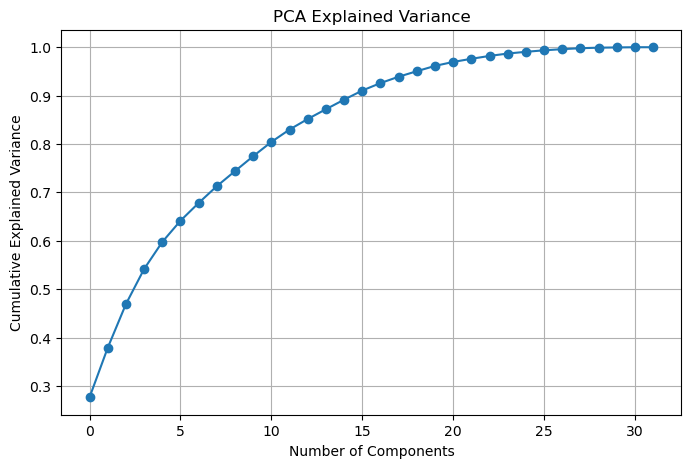

In [6]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

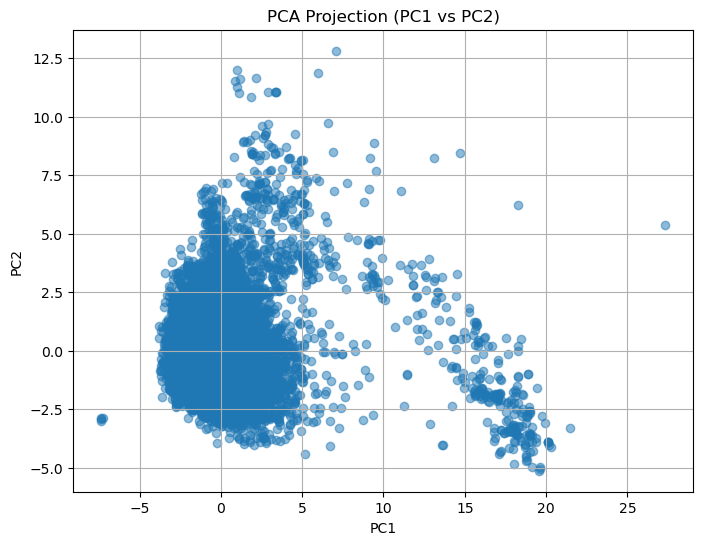

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.grid(True)
plt.show()

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(feature_cols_B))],
    index=feature_cols_B
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32
Sample_ID,-0.036188,-0.307112,0.099642,0.023271,0.193864,0.321438,-0.107279,-0.232930,-0.022420,-0.215028,0.041974,0.181158,0.180866,-0.328585,0.087514,0.270763,-0.464784,0.021630,-0.164471,-0.066242,-0.245838,0.137054,0.206290,-0.040166,-0.095552,-0.037798,0.037234,0.007413,0.004534,0.020694,-0.022169,0.000134
Latitude_Degrees,0.001770,0.069322,-0.355743,0.333248,0.197956,-0.251382,0.060781,-0.013835,0.118971,0.081599,0.025736,0.027322,0.021928,-0.111562,-0.030115,-0.019977,0.362722,0.003855,-0.236956,0.041302,-0.172709,0.379357,0.437076,-0.022303,-0.241177,-0.030803,-0.006359,-0.017403,0.007904,-0.013186,0.021437,0.000925
Longitude_Degrees,0.067413,0.100556,0.333246,-0.155336,-0.391177,-0.074857,-0.049719,0.050683,0.072532,0.065990,-0.013044,-0.045951,-0.174780,0.268286,-0.000773,-0.302148,-0.353504,0.044151,0.010536,0.024745,-0.082125,0.317113,0.447507,-0.078981,-0.170780,0.077528,0.040146,-0.022178,-0.002457,0.044223,0.009696,0.001320
Distance_to_Shore,-0.004850,0.025434,0.019920,-0.148110,-0.088852,0.411281,-0.221636,0.253099,0.362158,0.278221,0.080433,0.596552,-0.014204,0.077968,-0.155756,0.125554,0.240869,-0.013809,0.007581,0.051187,0.010301,0.055840,0.014327,-0.050027,0.003426,-0.041171,-0.022562,-0.004963,0.019988,0.006686,0.007105,0.000241
Turbidity,0.089562,0.025346,-0.022813,0.286010,-0.152205,0.305670,0.033283,-0.256889,-0.202493,-0.100678,-0.232750,0.168661,0.181796,0.437932,0.546166,-0.030776,0.205399,-0.041224,0.093247,0.001839,-0.014124,0.068741,-0.018946,0.013713,-0.075028,-0.022422,0.047057,0.010697,-0.030203,0.001186,0.006527,0.000302


In [11]:
loadings["PC1"].sort_values(key=abs, ascending=False).head(10)

SSTA_DHW_Standard_Deviation    0.317378
SSTA_FrequencyMean             0.295645
SSTA_Standard_Deviation        0.294332
TSA_DHWMax                     0.286621
TSA_FrequencyMean              0.279086
SSTA_DHWMax                    0.275271
TSA_Frequency                  0.263704
TSA_DHW                        0.261212
SSTA_DHW                       0.253644
TSA_Maximum                    0.221800
Name: PC1, dtype: float64

In [12]:
loadings["PC2"].sort_values(key=abs, ascending=False).head(10)

Temperature_Mean                    -0.430005
Temperature_Kelvin                  -0.416157
Temperature_Minimum                 -0.382098
TSA                                 -0.335375
Sample_ID                           -0.307112
Windspeed                            0.211966
Temperature_Maximum                 -0.192555
SSTA                                -0.191187
SSTA_Frequency_Standard_Deviation    0.174616
ClimSST                             -0.112954
Name: PC2, dtype: float64

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


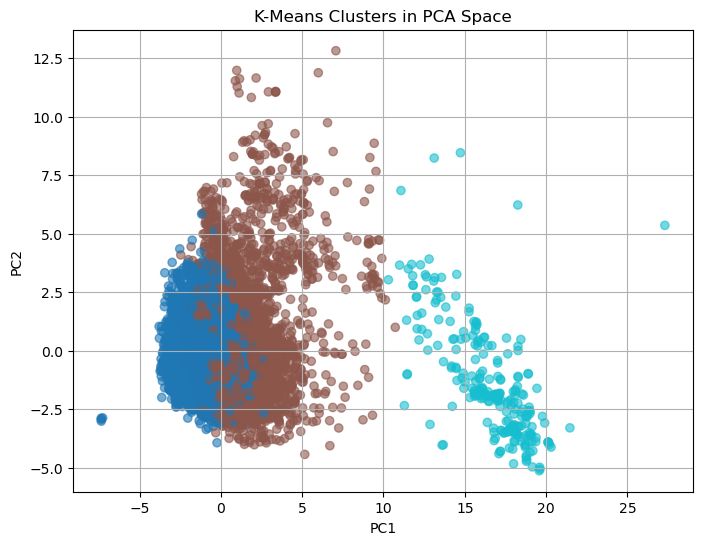

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :5])  # use top PCs

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.grid(True)
plt.show()